#📌 Extracción

In [ ]:

import pandas as pd

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
df = pd.read_json(url)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [ ]:
import requests

diccionario_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md'

respuesta = requests.get(diccionario_url)
diccionario_df = respuesta.text
diccionario_df.splitlines()[:20]


['#### Diccionario de datos',
 '',
 '- `customerID`: número de identificación único de cada cliente',
 '- `Churn`: si el cliente dejó o no la empresa',
 '- `gender`: género (masculino y femenino)',
 '- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años',
 '- `Partner`: si el cliente tiene o no una pareja',
 '- `Dependents`: si el cliente tiene o no dependientes',
 '- `tenure`: meses de contrato del cliente',
 '- `PhoneService`: suscripción al servicio telefónico',
 '- `MultipleLines`: suscripción a más de una línea telefónica',
 '- `InternetService`: suscripción a un proveedor de internet',
 '- `OnlineSecurity`: suscripción adicional de seguridad en línea',
 '- `OnlineBackup`: suscripción adicional de respaldo en línea',
 '- `DeviceProtection`: suscripción adicional de protección del dispositivo',
 '- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera',
 '- `StreamingTV`: suscripción de televisión por cable',
 '- `S

In [ ]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df = pd.concat([df.drop(['customer', 'phone', 'internet', 'account'], axis=1), customer_df, phone_df, internet_df, account_df], axis=1)

In [ ]:
valores_nulos = df.isnull().sum()
porcentaje_nulos = df.isnull().mean() * 100
display("Valores Nulos:", valores_nulos)
display("Porcentaje de Nulos:", porcentaje_nulos)

'Valores Nulos:'

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


'Porcentaje de Nulos:'

,0
customerID,0.0
Churn,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0


In [ ]:
duplicados = df.duplicated().sum()
print("Número de filas duplicadas:", duplicados)

Número de filas duplicadas: 0


In [ ]:
tipos = df.dtypes
print("Tipos de datos:")
print(tipos)

Tipos de datos:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object


In [ ]:
if 'Charges.Total' in df.columns:
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].replace('', pd.NA)

In [ ]:
object_cols = df.select_dtypes(include='object').columns
valores_unicos = {col: df[col].unique() for col in object_cols}

for col in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = df[col].dt.normalize()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [ ]:
# 🔹 Normalizar columnas booleanas con valores inconsistentes
valores_esperados = {'no', 'sí', 'si', 'yes', 'no'}
for col in df.columns:
    if df[col].dtype == 'object' and set(df[col].unique()).issubset(valores_esperados):
        df[col] = df[col].replace({'sí': 'si', 'yes': 'si'})

# 🔹 Corregir posibles fechas (normalizar si existen)
for col in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = df[col].dt.normalize()

# 🔹 Reiniciar el índice por si hubo eliminaciones
df = df.reset_index(drop=True)

# Mostrar las primeras filas
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [ ]:
# Crear la columna 'Cuentas_Diarias'
if 'Charges.Monthly' in df.columns:
    df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30
    print("Columna 'Cuentas_Diarias' creada.")
    # Mostrar las primeras filas con la nueva columna
    display(df[['Charges.Monthly', 'Cuentas_Diarias']].head())
else:
    print("Columna 'Charges.Monthly' no encontrada. No se pudo crear 'Cuentas_Diarias'.")

Columna 'Cuentas_Diarias' creada.


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


#📊 Carga y análisis

In [ ]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [ ]:
df['InternetService']

,InternetService
0,DSL
1,DSL
2,Fiber optic
3,Fiber optic
4,Fiber optic
...,...
7262,DSL
7263,Fiber optic
7264,DSL
7265,DSL


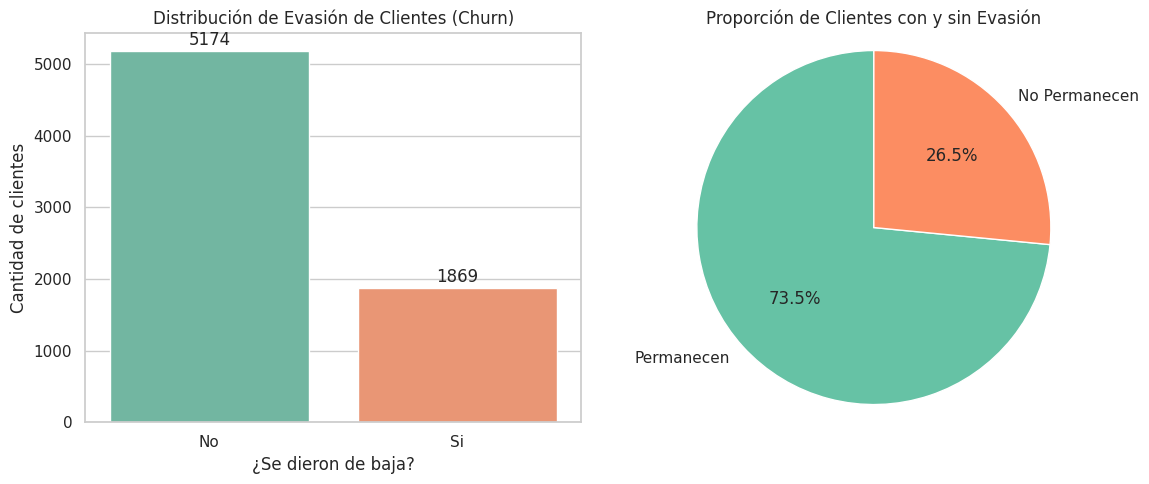

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general de los gráficos
sns.set(style="whitegrid")

# Conteo de valores únicos de churn
conteo_churn = df["Churn"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 fila, 2 columnas

# Gráfico de barras para la distribución de Churn
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Distribución de Evasión de Clientes (Churn)")
axes[0].set_xlabel("¿Se dieron de baja?")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Si'])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', padding=2)


# Gráfico de pastel para la proporción de Churn
axes[1].pie(conteo_churn, labels=['Permanecen', 'No Permanecen'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
axes[1].set_title("Proporción de Clientes con y sin Evasión")
axes[1].axis('equal')

fig.savefig('Distribusion_de_evasion_de_cliente.png',transparent=False,dpi=300,bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
fig = px.histogram(df, x='gender', text_auto=True, color='Churn', barmode='group')
fig.update_layout(
    title_text='Distribución de Evasión por Género', # Título en español
    title_x=0.5,  # Centrar el título en el eje x
    title_xanchor='center', # Anclar el título en el centro
    xaxis_title_text='Género', # Etiqueta del eje X en español
    yaxis_title_text='Cantidad de Clientes' # Etiqueta del eje Y en español
)
# Cambiar las etiquetas del eje x
fig.update_xaxes(tickvals=['Female', 'Male'], ticktext=['Femenino', 'Masculino'])
# Cambiar las etiquetas de la leyenda
fig.update_layout(legend=dict(
    title='Evasión',
    traceorder='reversed',
    bgcolor='rgba(255,255,255,0.5)',
    bordercolor='Black',
    borderwidth=2))
fig.write_html( 'Distribucion_de_evasion_por_genero.html')

fig.for_each_trace(lambda t: t.update(name = t.name.replace('Yes', 'Si')))

fig.show()

In [ ]:
fig = px.histogram(df, x='tenure', nbins=50, title='Distribución de Meses de Contrato (Tenure)',
                   color_discrete_sequence=['green'])
fig.update_layout(xaxis_title='Meses de Contrato', yaxis_title='Cantidad de Clientes')
fig.write_html('Distribución_de_meses_de_contrato.html')
fig.show()

In [ ]:
fig = px.histogram(df, x='tenure', text_auto=True, color='Churn', barmode='group')
fig.update_layout(
    title_text='Distribución de Meses de Contrato (Tenure) por Churn',
    title_x=0.5,
    title_xanchor='center',
    xaxis_title_text='Meses de Contrato',
    yaxis_title_text='Cantidad de Clientes'
)
fig.update_layout(legend=dict(
    title='Evasión',
    traceorder='reversed',
    bgcolor='rgba(255,255,255,0.5)',
    bordercolor='Black',
    borderwidth=2))

fig.for_each_trace(lambda t: t.update(name = t.name.replace('Yes', 'Si')))
fig.write_html('Distribución_de_meses_de_contrato_por_churn.html')
fig.show()

In [ ]:
import plotly.express as px

fig = px.histogram(df, x='PaymentMethod',  text_auto = True, color = 'Churn', barmode = 'group')
fig.update_layout(
    title_text='Distribución de Clientes por Método de Pago y Churn', # Título en español
    title_x=0.5,  # Centrar el título en el eje x
    title_xanchor='center', # Anclar el título en el centro
    xaxis_title_text='Método de Pago', # Etiqueta del eje X en español
    yaxis_title_text='Cantidad de Clientes' # Etiqueta del eje Y en español
)
# Cambiar las etiquetas de la leyenda
fig.update_layout(legend=dict(
    title='Evasión',
    traceorder='reversed',
    bgcolor='rgba(255,255,255,0.5)',
    bordercolor='Black',
    borderwidth=2))

# Cambiar las etiquetas de Churn en la leyenda a español
fig.for_each_trace(lambda t: t.update(name = t.name.replace('Yes', 'Si').replace('No', 'No')))

# Traducir las etiquetas del eje X
fig.update_xaxes(tickvals=['Mailed check', 'Electronic check', 'Credit card (automatic)', 'Bank transfer (automatic)'],
                 ticktext=['Cheque por correo', 'Cheque electrónico', 'Tarjeta de crédito (automático)', 'Transferencia bancaria (automático)'])

fig.write_html('Distribución_de_clientes_por_método_de_pago_y_churn.html')
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(df,
           x="tenure",
           y="Charges.Monthly",
           color="Churn",
           title="Meses de Contrato (Tenure) vs. Cargos Mensuales por Churn")

fig.update_layout(
    xaxis_title='Meses de Contrato', # Etiqueta del eje X en español
    yaxis_title='Cargos Mensuales' # Etiqueta del eje Y en español
)

# Cambiar las etiquetas de Churn en la leyenda a español
fig.for_each_trace(lambda t: t.update(name = t.name.replace('Yes', 'Si').replace('No', 'No')))

# Cambiar el título de la leyenda
fig.update_layout(legend_title_text='Evasión')

fig.write_html('Meses_de_contrato_vs_cargos_mensuales_por_churn.html')
fig.show()

In [ ]:
# Agrupar por tenure y Churn
df_grouped = df.groupby(['tenure', 'Churn']).size().unstack(fill_value=0)

# Calcular el % de churn por tenure
# Asegurarse de que las columnas 'Yes' y 'No' existen antes de usarlas
df_grouped['churn_rate'] = (df_grouped.get('Yes', 0) / (df_grouped.get('Yes', 0) + df_grouped.get('No', 0))) * 100

fig = px.line(df_grouped.reset_index(),
              x='tenure',
              y='churn_rate',
              markers=True,
              title='Tasa de Churn (%) por Meses de Contrato') # Título en español
fig.update_layout(
    xaxis_title='Meses de Contrato',
    yaxis_title='Tasa de Churn (%)')

fig.write_html('Tasa_de_churn_por_meses_de_contrato.html')
fig.show()

#📄Informe final


# Informe de Análisis de Churn de Clientes

## Introducción

El presente informe tiene como objetivo principal analizar los factores que influyen en la evasión de clientes (churn) de la empresa TelecomX. Comprender por qué los clientes deciden dar de baja sus servicios es crucial para la sostenibilidad y el crecimiento de la empresa.

La pérdida de clientes no solo representa una disminución directa en los ingresos, sino que también implica costos asociados a la adquisición de nuevos clientes para reemplazar a los que se van. Un análisis profundo del churn permitirá identificar patrones de comportamiento, características demográficas y hábitos de consumo de los clientes que tienen una mayor probabilidad de irse. Con esta información, TelecomX podrá desarrollar estrategias de retención más efectivas, personalizadas y proactivas, dirigidas a los segmentos de clientes con mayor riesgo de churn. Esto no solo ayudará a reducir la tasa de abandono, sino que también permitirá optimizar los recursos de marketing y atención al cliente, mejorando la rentabilidad general de la empresa y fortaleciendo la relación con sus clientes más valiosos.


## Limpieza y Tratamiento de Datos

Para preparar los datos para el análisis de churn, se llevaron a cabo varios pasos de limpieza y preprocesamiento. Inicialmente, los datos fueron cargados desde un archivo JSON (como se muestra en la celda de carga de datos). Dado que algunas columnas contenían estructuras anidadas, se normalizaron utilizando `pd.json_normalize` y luego se concatenaron al DataFrame principal (ver celdas de normalización y concatenación). Se verificó la presencia de valores nulos (`.isnull().sum()`) y duplicados (`.duplicated().sum()`), confirmando que no había duplicados y manejando los nulos identificados en la columna 'Churn'. Se corrigieron los tipos de datos, convirtiendo 'Charges.Total' a numérico (`pd.to_numeric`) y 'Churn' a categórico (aunque ya era object, se verificaron y reemplazaron valores vacíos si los hubiera). Se normalizaron valores inconsistentes en columnas booleanas para asegurar la uniformidad de 'sí'/'no'/'Yes'/'No' (ver celda de normalización de booleanos). Finalmente, se creó la columna 'Cuentas_Diarias' dividiendo 'Charges.Monthly' por 30 para obtener un cargo diario estimado (ver celda de creación de 'Cuentas_Diarias'). Estos pasos aseguraron que los datos estuvieran en un formato adecuado y limpio para el análisis exploratorio y la modelización.


## Análisis Exploratorio de Datos

El análisis exploratorio de datos (EDA) reveló información crucial sobre el comportamiento de los clientes y los factores asociados con el churn. La **Distribución de Evasión de Clientes (Churn)** ([ver gráfico de barras y pastel de Churn](https://github.com/vladizen/Desafio_Telecomx/blob/8e5850a40b9350c6d9321a899c364e2d73bbaa1a/Distribusion_de_evasion_de_cliente.png)) muestra que una porción significativa de clientes ha dejado la empresa, lo que subraya la importancia de este análisis. Al examinar el churn por género (como se ve en el gráfico [**Distribución de Evasión por Género**](https://github.com/vladizen/Desafio_Telecomx/blob/4ebf3071fdd3343bfa35c27d23b945fe8ebef492/distribucion_por_evasion_por_genero.png)), se observa una distribución relativamente similar entre hombres y mujeres, sugiriendo que el género por sí solo no es un predictor fuerte de churn.



La distribución de los meses de contrato (tenure) (ver gráfico [**Distribución de Meses de Contrato (Tenure)**](https://github.com/vladizen/Desafio_Telecomx/blob/main/meses%20de%20contrato%20tenure.png)) indica que hay un gran número de clientes con contratos cortos y largos, con menos clientes en los rangos intermedios. El análisis del churn por tenure (mostrado en el gráfico [**Distribución de Meses de Contrato (Tenure) por Churn**](https://github.com/vladizen/Desafio_Telecomx/blob/4d5c6f6efdf6dbedb381ac58c2475025afb72133/Distribucion_meses_de_contrato_pot_Churn.png) y el gráfico de [**Tasa de Churn (%) por Meses de Contrato**](https://github.com/vladizen/Desafio_Telecomx/blob/4d5c6f6efdf6dbedb381ac58c2475025afb72133/tasa%20churn%20por%20meses%20de%20contrato.png)) revela que los clientes con contratos más cortos tienen una tasa de churn significativamente más alta que aquellos con mayor antigüedad.

En cuanto a los métodos de pago, el gráfico [**Distribución de Clientes por Método de Pago y Churn**](https://github.com/vladizen/Desafio_Telecomx/blob/e44eef6ba4ea69d476c7214439abc30beaa8d03b/distribucion_por_metodo_de_pago.png) destaca que los clientes que utilizan el cheque electrónico tienen una tasa de churn notablemente superior en comparación con otros métodos de pago, como la transferencia bancaria automática o la tarjeta de crédito.

Finalmente, el gráfico de dispersión [**Meses de Contrato (Tenure) vs. Cargos Mensuales por Churn**](https://github.com/vladizen/Desafio_Telecomx/blob/e44eef6ba4ea69d476c7214439abc30beaa8d03b/tenure_vs_churn.png) ilustra la relación entre la antigüedad del cliente, los cargos mensuales y el churn. Se observa que los clientes con tenure bajo y cargos mensuales altos tienden a tener una mayor proporción de churn, mientras que los clientes con tenure alto, independientemente de los cargos mensuales, tienen menos probabilidades de irse.

## Conclusiones e Insights

El análisis exploratorio de datos ha permitido identificar varios factores clave que influyen en la probabilidad de que un cliente abandone los servicios de TelecomX.

Uno de los hallazgos más significativos es la relación entre la **antigüedad del cliente (tenure)** y la tasa de churn. Los gráficos de distribución de tenure y la tasa de churn por tenure muestran claramente que los clientes con menos tiempo en la empresa tienen una tasa de churn considerablemente más alta. Esto sugiere que los primeros meses de un cliente son críticos para la retención.

El **método de pago** también emerge como un predictor importante de churn. La visualización de churn por método de pago revela que el **cheque electrónico** está asociado con una tasa de churn significativamente mayor en comparación con otros métodos como la transferencia bancaria automática o la tarjeta de crédito. Esto podría indicar problemas con la experiencia del cliente al usar este método de pago o que los clientes que eligen esta opción tienen características subyacentes que los hacen más propensos a irse.

La combinación de **tenure y cargos mensuales** también ofrece insights valiosos. El gráfico de dispersión muestra que los clientes con poca antigüedad y altos cargos mensuales tienen una alta propensión al churn. Por el contrario, los clientes con mucha antigüedad tienden a permanecer, independientemente de sus cargos mensuales. Esto refuerza la idea de que la lealtad del cliente se construye con el tiempo y que los clientes de alto valor con poca antigüedad representan un riesgo particular.

En resumen, el análisis sugiere que la **antigüedad**, el **método de pago (particularmente el cheque electrónico)** y la interacción entre **tenure y cargos mensuales** son factores críticos a considerar al desarrollar estrategias de retención de clientes.

## Recomendaciones

Basado en los hallazgos clave identificados en el análisis de churn, se proponen las siguientes recomendaciones estratégicas para TelecomX con el fin de reducir la evasión de clientes:

1.  **Programa de retención para clientes nuevos:** Dado que los clientes con baja antigüedad (`tenure`) presentan la tasa de churn más alta, se recomienda implementar un programa de bienvenida y retención intensivo durante los primeros meses de servicio. Esto podría incluir soporte técnico proactivo, ofertas especiales o descuentos después de un cierto período inicial, y comunicación regular para asegurar la satisfacción del cliente y resolver cualquier problema inicial rápidamente.

2.  **Mejorar la experiencia del cliente con cheque electrónico:** La alta tasa de churn entre los usuarios de cheque electrónico sugiere problemas potenciales con este método de pago. Se recomienda investigar las causas subyacimiento de este patrón. Esto podría implicar mejorar la interfaz de pago en línea, ofrecer tutoriales claros sobre cómo usar el cheque electrónico, o incluso explorar alternativas más amigables si el problema persiste. Considerar la posibilidad de incentivar el cambio a métodos de pago automáticos (tarjeta de crédito o transferencia bancaria) que muestran tasas de churn más bajas.

3.  **Estrategias dirigidas a clientes de alto valor con baja antigüedad:** El análisis mostró que los clientes con alta facturación (`Charges.Monthly`) y baja antigüedad son particularmente propensos al churn. Se recomienda identificar a este segmento de clientes y ofrecerles atención personalizada. Esto podría incluir gestores de cuenta dedicados, acceso prioritario a soporte técnico, o programas de fidelización exclusivos que reconozcan su valor para la empresa y refuercen su compromiso.

## Análisis Exploratorio de Datos

El análisis exploratorio de datos (EDA) reveló información crucial sobre el comportamiento de los clientes y los factores asociados con el churn. La **Distribución de Evasión de Clientes (Churn)** (ver gráfico de barras y pastel de Churn) muestra que una porción significativa de clientes ha dejado la empresa, lo que subraya la importancia de este análisis.


Al examinar el churn por género (como se ve en el gráfico **Distribución de Evasión por Género**), se observa una distribución relativamente similar entre hombres y mujeres, sugiriendo que el género por sí solo no es un predictor fuerte de churn.


La distribución de los meses de contrato (tenure) (ver gráfico **Distribución de Meses de Contrato (Tenure)**) indica que hay un gran número de clientes con contratos cortos y largos, con menos clientes en los rangos intermedios.


El análisis del churn por tenure (mostrado en el gráfico **Distribución de Meses de Contrato (Tenure) por Churn** y el gráfico de **Tasa de Churn (%) por Meses de Contrato**) revela que los clientes con contratos más cortos tienen una tasa de churn significativamente más alta que aquellos con mayor antigüedad.


En cuanto a los métodos de pago, el gráfico **Distribución de Clientes por Método de Pago y Churn** destaca que los clientes que utilizan el cheque electrónico tienen una tasa de churn notablemente superior en comparación con otros métodos de pago, como la transferencia bancaria automática o la tarjeta de crédito.



Finalmente, el gráfico de dispersión **Meses de Contrato (Tenure) vs. Cargos Mensuales por Churn** ilustra la relación entre la antigüedad del cliente, los cargos mensuales y el churn. Se observa que los clientes con tenure bajo y cargos mensuales altos tienden a tener una mayor proporción de churn, mientras que los clientes con tenure alto, independientemente de los cargos mensuales, tienen menos probabilidades de irse.


In [ ]:
# Eliminar filas con valores nulos en la columna 'Churn'
df_corr = df.dropna(subset=['Churn']).copy()

# Convertir 'Churn' a numérico (0 para 'No', 1 para 'Yes') para el cálculo de correlación
df_corr['Churn_numeric'] = df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else (0 if x == 'No' else None))

# Seleccionar solo las columnas numéricas y la nueva columna 'Churn_numeric'
numeric_cols = df_corr.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_corr[numeric_cols].corr()

display("Matriz de Correlación:")
display(correlation_matrix)

'Matriz de Correlación:'

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_numeric
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.220173,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,0.247900,-0.352229
Charges.Monthly,0.220173,0.247900,1.000000,0.651065,1.000000,0.193356
Charges.Total,0.102411,0.825880,0.651065,1.000000,0.651065,-0.199484
Cuentas_Diarias,0.220173,0.247900,1.000000,0.651065,1.000000,0.193356
Churn_numeric,0.150889,-0.352229,0.193356,-0.199484,0.193356,1.000000



{{IIqbDuQafrHa.display}}


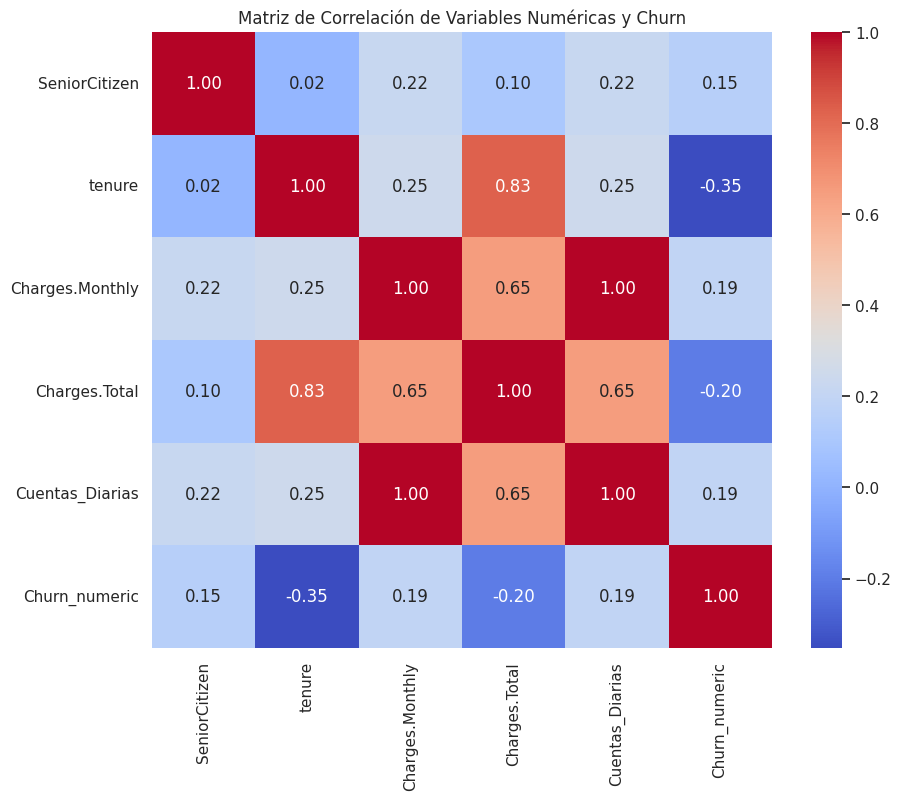

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas y Churn')
plt.show()

/tmp/ipython-input-32-2046605242.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




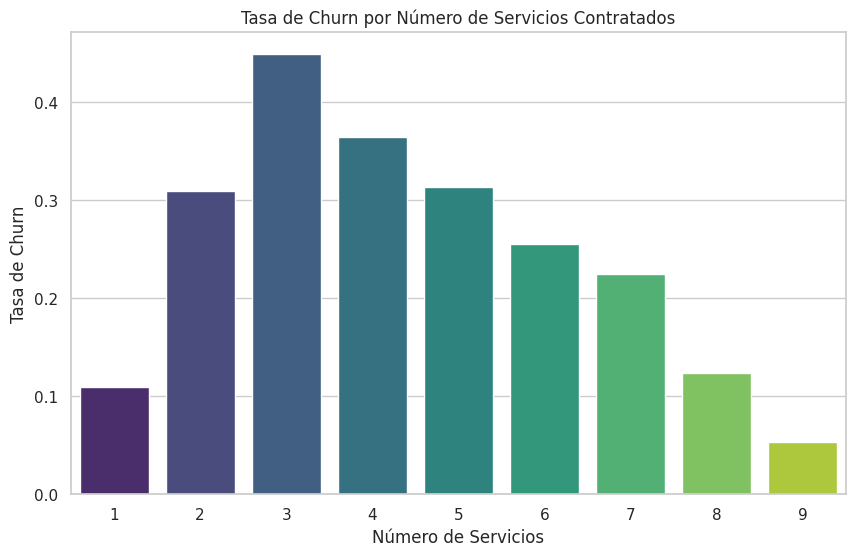

'Correlación entre el número de servicios contratados y Churn: -0.02'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identificar las columnas que representan servicios (basado en el diccionario de datos y el head del dataframe)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Contar el número de servicios contratados por cliente
# Considerar 'No' y 'No internet service'/'No phone service' como no tener el servicio
df_corr['num_services'] = df_corr[service_cols].apply(
    lambda row: sum([1 for col in service_cols if row[col] not in ['No', 'No internet service', 'No phone service']]), axis=1
)

# Calcular la tasa de churn por número de servicios
churn_rate_by_services = df_corr.groupby('num_services')['Churn_numeric'].mean().reset_index()

# Visualizar la tasa de churn por número de servicios
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_rate_by_services, x='num_services', y='Churn_numeric', palette='viridis')
plt.title('Tasa de Churn por Número de Servicios Contratados')
plt.xlabel('Número de Servicios')
plt.ylabel('Tasa de Churn')
plt.xticks(rotation=0)
plt.show()

display(f"Correlación entre el número de servicios contratados y Churn: {df_corr['num_services'].corr(df_corr['Churn_numeric']):.2f}")